# 📊 Retail Store Inventory — Exploratory Data Analysis (EDA)

**Target Variable:** `Units Sold`  
**Problem Type:** Regression

In this notebook we explore the data visually to understand:
- How is our target (`Units Sold`) distributed?
- Which numerical features are related to Units Sold?
- How do categorical features (Category, Region, Season, Weather) affect sales?
- Are there any time-based patterns?
- Which features are correlated with each other?

> **Tip for beginners:** Run each cell one by one (Shift + Enter) and read the comments to understand what each step does.

---
## 1. Import Libraries

We need:
- **pandas** → to work with tabular data
- **numpy** → for numerical operations
- **matplotlib** → base plotting library
- **seaborn** → makes prettier plots on top of matplotlib

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore unnecessary warnings
import warnings
warnings.filterwarnings('ignore')

# Set a clean plot style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams['figure.dpi'] = 100

print('Libraries loaded!')

Libraries loaded!


---
## 2. Load & Quick Look at the Data

In [2]:
df = pd.read_csv('retail_store_inventory.csv')

# Convert Date column so we can use it for time analysis later
df['Date'] = pd.to_datetime(df['Date'])

print(f'Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head()

Dataset shape: 73,100 rows × 15 columns


,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer


In [3]:
# Separate numerical and categorical columns for later use
numerical_cols = ['Inventory Level', 'Units Sold', 'Units Ordered',
                  'Demand Forecast', 'Price', 'Discount',
                  'Competitor Pricing', 'Holiday/Promotion']

categorical_cols = ['Category', 'Region', 'Weather Condition', 'Seasonality']

TARGET = 'Units Sold'

print(f'Target variable : {TARGET}')
print(f'Numerical features  ({len(numerical_cols)}): {numerical_cols}')
print(f'Categorical features ({len(categorical_cols)}): {categorical_cols}')

Target variable : Units Sold
Numerical features  (8): ['Inventory Level', 'Units Sold', 'Units Ordered', 'Demand Forecast', 'Price', 'Discount', 'Competitor Pricing', 'Holiday/Promotion']
Categorical features (4): ['Category', 'Region', 'Weather Condition', 'Seasonality']


---
## 3. Target Variable Analysis — How is `Units Sold` distributed?

Before looking at relationships, we first need to understand our target on its own.

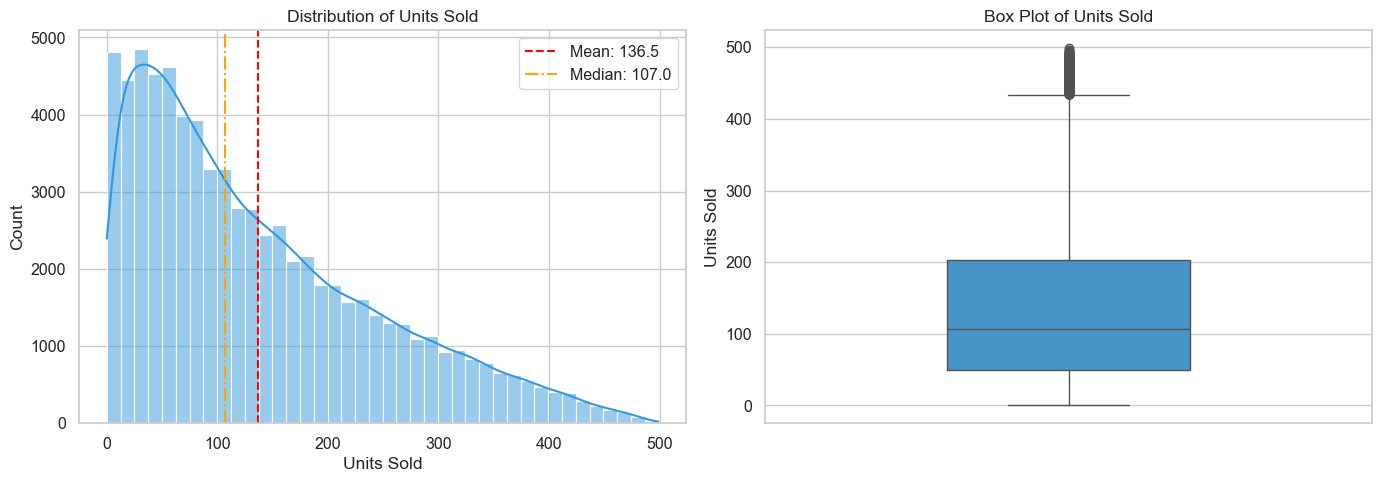

Mean     : 136.46
Median   : 107.00
Std Dev  : 108.92
Skewness : 0.905  (close to 0 = symmetric)
Min      : 0
Max      : 499


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram — shows the shape of the distribution
sns.histplot(df[TARGET], kde=True, bins=40, color='#3498db', ax=axes[0], edgecolor='white')
axes[0].axvline(df[TARGET].mean(), color='red', linestyle='--', label=f'Mean: {df[TARGET].mean():.1f}')
axes[0].axvline(df[TARGET].median(), color='orange', linestyle='-.', label=f'Median: {df[TARGET].median():.1f}')
axes[0].set_title(f'Distribution of {TARGET}')
axes[0].legend()

# Box plot — shows spread and outliers
sns.boxplot(y=df[TARGET], color='#3498db', width=0.4, ax=axes[1])
axes[1].set_title(f'Box Plot of {TARGET}')

plt.tight_layout()
plt.show()

print(f'Mean     : {df[TARGET].mean():.2f}')
print(f'Median   : {df[TARGET].median():.2f}')
print(f'Std Dev  : {df[TARGET].std():.2f}')
print(f'Skewness : {df[TARGET].skew():.3f}  (close to 0 = symmetric)')
print(f'Min      : {df[TARGET].min()}')
print(f'Max      : {df[TARGET].max()}')

---
## 4. Numerical Features vs Units Sold

**Scatter plots** help us see if there's a relationship between a numerical feature and the target.  
- If dots form a pattern (line, curve) → there's a relationship  
- If dots are randomly scattered → weak/no relationship

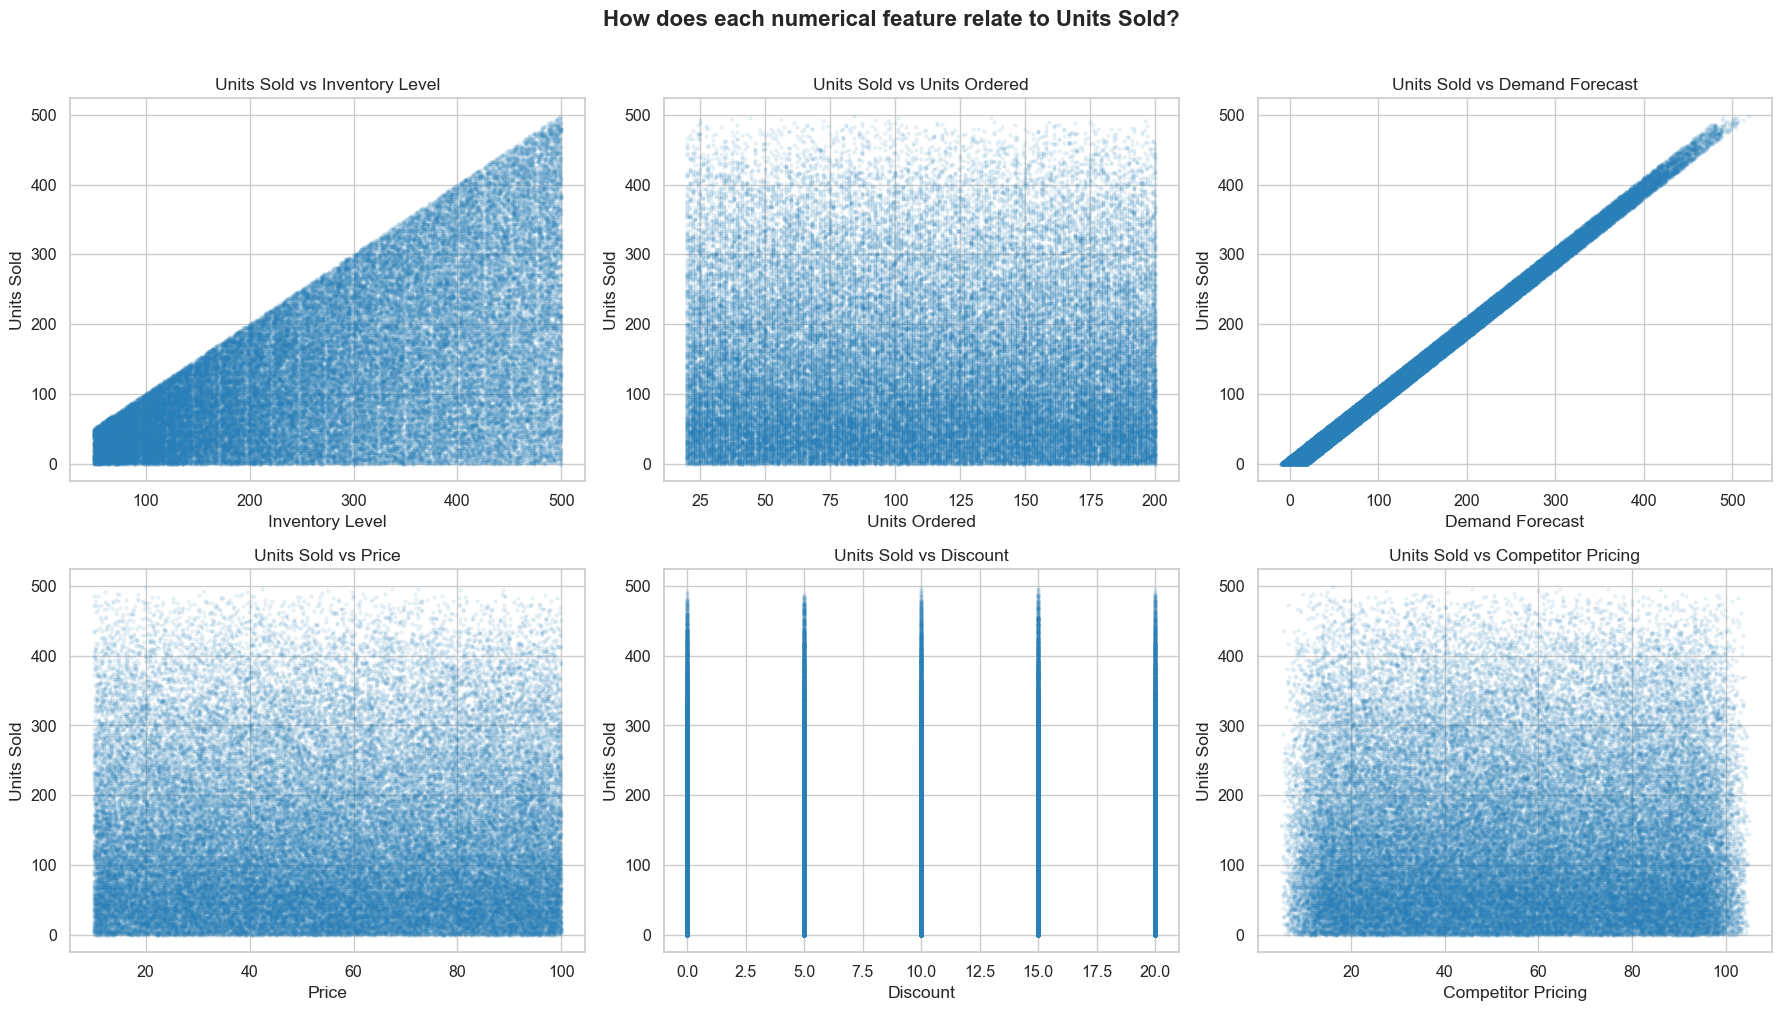

In [5]:
# Features to plot against Units Sold (excluding the target itself)
features_to_plot = ['Inventory Level', 'Units Ordered', 'Demand Forecast',
                    'Price', 'Discount', 'Competitor Pricing']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(features_to_plot):
    axes[i].scatter(df[col], df[TARGET], alpha=0.08, s=5, color='#2980b9')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel(TARGET)
    axes[i].set_title(f'{TARGET} vs {col}')

plt.suptitle('How does each numerical feature relate to Units Sold?',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 4.1 Closer look: Demand Forecast vs Units Sold

Demand Forecast is the predicted demand — let's see how close it is to actual sales.

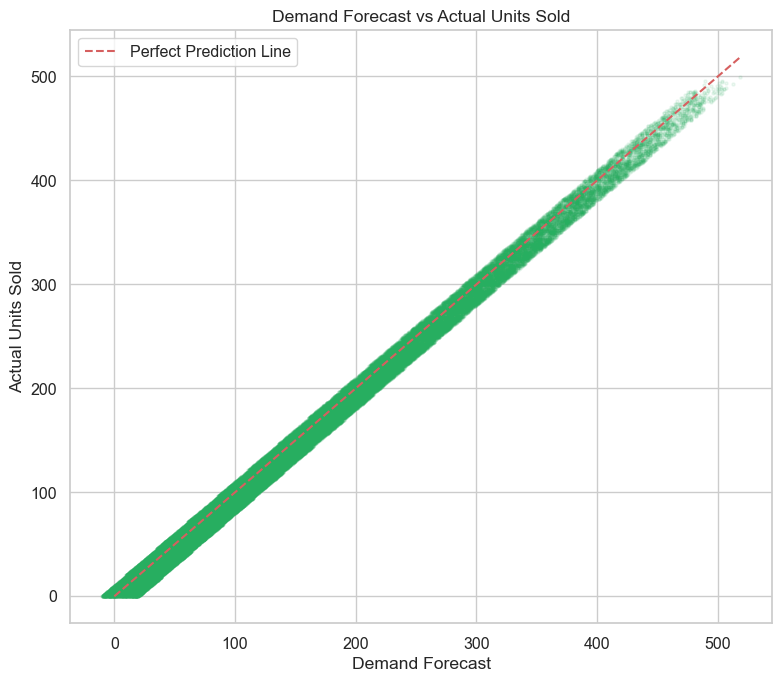

In [6]:
fig, ax = plt.subplots(figsize=(8, 7))

ax.scatter(df['Demand Forecast'], df[TARGET], alpha=0.08, s=5, color='#27ae60')

# Draw a diagonal line — if forecast is perfect, all points sit on this line
max_val = max(df['Demand Forecast'].max(), df[TARGET].max())
ax.plot([0, max_val], [0, max_val], 'r--', linewidth=1.5, label='Perfect Prediction Line')

ax.set_xlabel('Demand Forecast')
ax.set_ylabel('Actual Units Sold')
ax.set_title('Demand Forecast vs Actual Units Sold')
ax.legend()
plt.tight_layout()
plt.show()

---
## 5. Correlation Heatmap

**Correlation** measures how strongly two numerical features move together:
- **+1** = perfect positive relationship (both go up together)
- **-1** = perfect negative relationship (one goes up, other goes down)
- **0** = no linear relationship

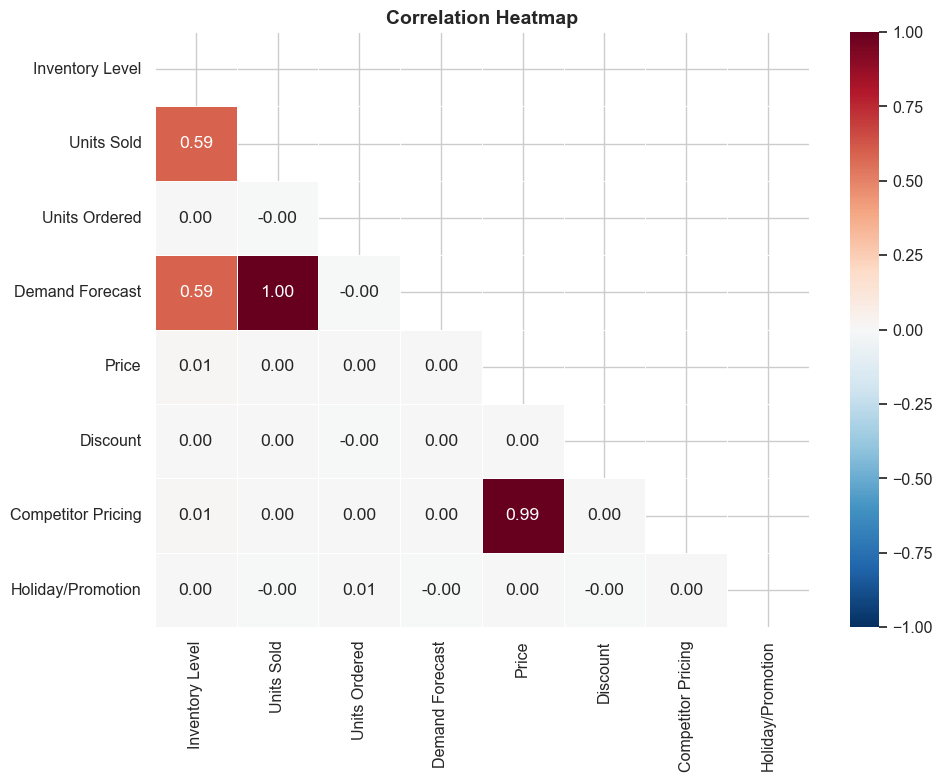

In [7]:
corr = df[numerical_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))

# mask the upper triangle to avoid duplicate info
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5, vmin=-1, vmax=1, ax=ax)

ax.set_title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.1 Which features correlate most with Units Sold?

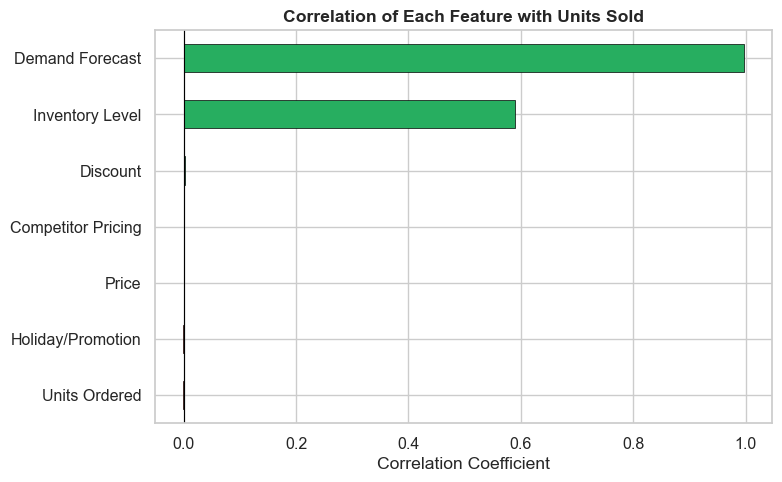


Correlation with Units Sold:
  Demand Forecast           → +0.997 (Strong Positive)
  Inventory Level           → +0.590 (Strong Positive)
  Discount                  → +0.003 (Weak Positive)
  Competitor Pricing        → +0.001 (Weak Positive)
  Price                     → +0.001 (Weak Positive)
  Units Ordered             → -0.001 (Weak Negative)
  Holiday/Promotion         → -0.000 (Weak Negative)


In [8]:
target_corr = corr[TARGET].drop(TARGET).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#e74c3c' if v < 0 else '#27ae60' for v in target_corr.values]
target_corr.plot(kind='barh', ax=ax, color=colors, edgecolor='black', linewidth=0.5)
ax.set_title(f'Correlation of Each Feature with {TARGET}', fontweight='bold')
ax.set_xlabel('Correlation Coefficient')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

# Print interpretation
print(f'\nCorrelation with {TARGET}:')
for feat, val in target_corr.sort_values(key=abs, ascending=False).items():
    strength = 'Strong' if abs(val) > 0.5 else 'Moderate' if abs(val) > 0.3 else 'Weak'
    direction = 'Positive' if val > 0 else 'Negative'
    print(f'  {feat:25s} → {val:+.3f} ({strength} {direction})')

---
## 6. Categorical Features vs Units Sold

**Box plots** help compare how Units Sold varies across different categories.  
- If boxes are at different heights → that feature influences sales  
- If boxes overlap a lot → that feature may not matter much

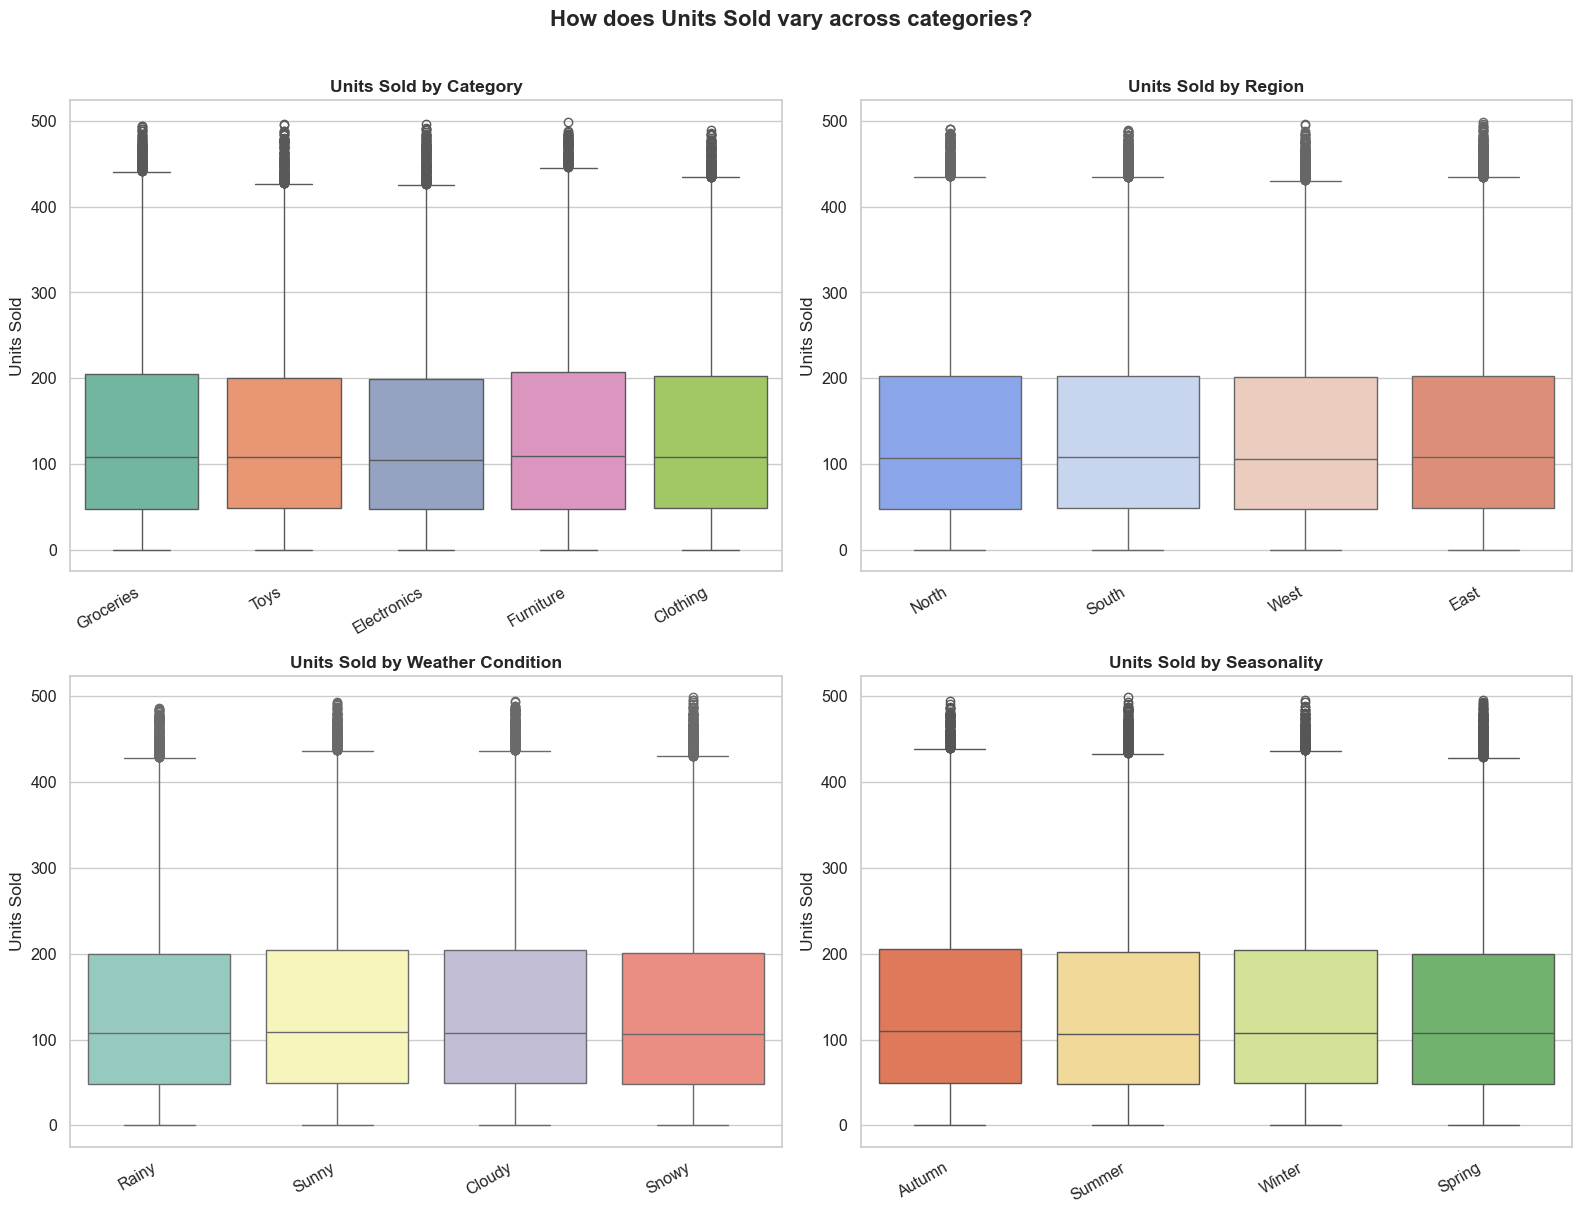

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

palettes = ['Set2', 'coolwarm', 'Set3', 'RdYlGn']

for i, col in enumerate(categorical_cols):
    sns.boxplot(data=df, x=col, y=TARGET, ax=axes[i], palette=palettes[i])
    axes[i].set_title(f'{TARGET} by {col}', fontweight='bold')
    axes[i].set_xlabel('')
    plt.setp(axes[i].get_xticklabels(), rotation=30, ha='right')

plt.suptitle('How does Units Sold vary across categories?',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 6.1 Average Units Sold by each categorical feature

Bar plots showing the **mean** Units Sold for each group.

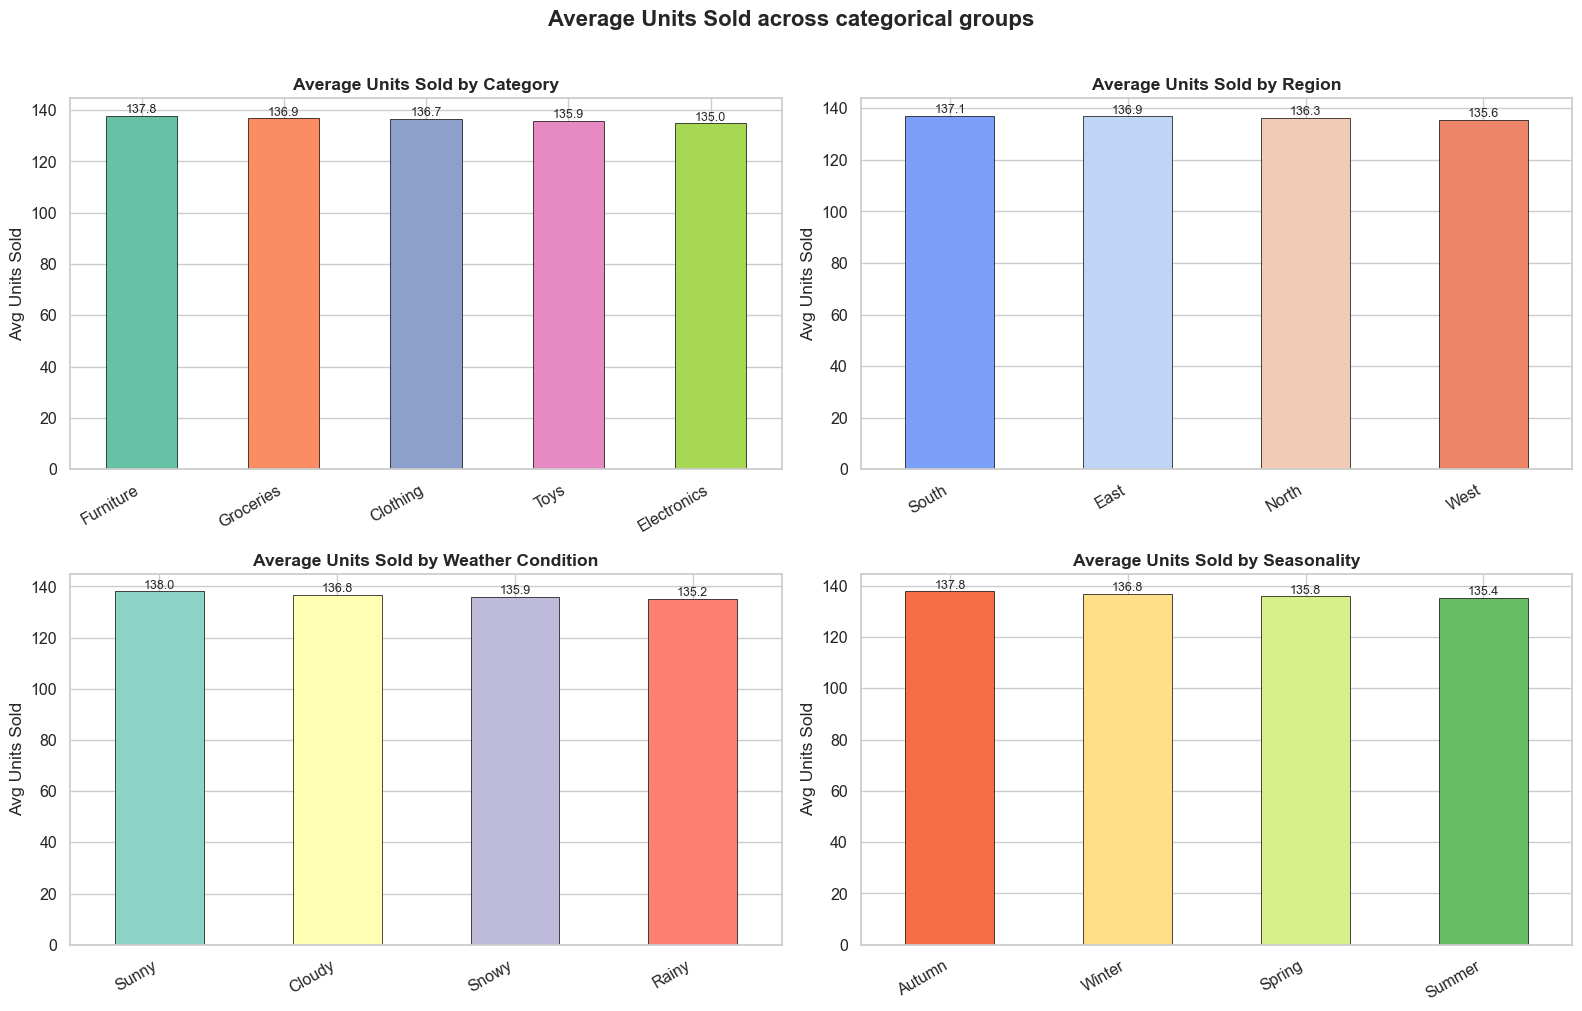

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    avg = df.groupby(col)[TARGET].mean().sort_values(ascending=False)
    avg.plot(kind='bar', ax=axes[i], color=sns.color_palette(palettes[i], len(avg)),
             edgecolor='black', linewidth=0.5)
    axes[i].set_title(f'Average {TARGET} by {col}', fontweight='bold')
    axes[i].set_ylabel(f'Avg {TARGET}')
    axes[i].set_xlabel('')
    plt.setp(axes[i].get_xticklabels(), rotation=30, ha='right')

    # Add value labels on top of bars
    for bar in axes[i].patches:
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                     f'{bar.get_height():.1f}', ha='center', fontsize=9)

plt.suptitle('Average Units Sold across categorical groups',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 6.2 Holiday/Promotion Impact on Units Sold

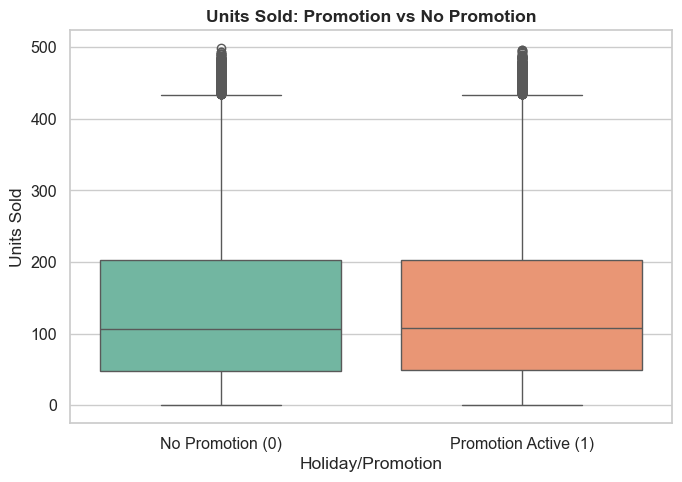

Avg Units Sold without promotion : 136.51
Avg Units Sold with promotion    : 136.42
Difference                       : -0.08


In [11]:
fig, ax = plt.subplots(figsize=(7, 5))

sns.boxplot(data=df, x='Holiday/Promotion', y=TARGET, palette='Set2', ax=ax)
ax.set_xticklabels(['No Promotion (0)', 'Promotion Active (1)'])
ax.set_title(f'{TARGET}: Promotion vs No Promotion', fontweight='bold')
plt.tight_layout()
plt.show()

# Print the difference
avg_no_promo = df[df['Holiday/Promotion'] == 0][TARGET].mean()
avg_promo = df[df['Holiday/Promotion'] == 1][TARGET].mean()
print(f'Avg Units Sold without promotion : {avg_no_promo:.2f}')
print(f'Avg Units Sold with promotion    : {avg_promo:.2f}')
print(f'Difference                       : {avg_promo - avg_no_promo:+.2f}')

---
## 7. Discount Analysis — Does discount drive more sales?

Let's see if higher discounts lead to more Units Sold.

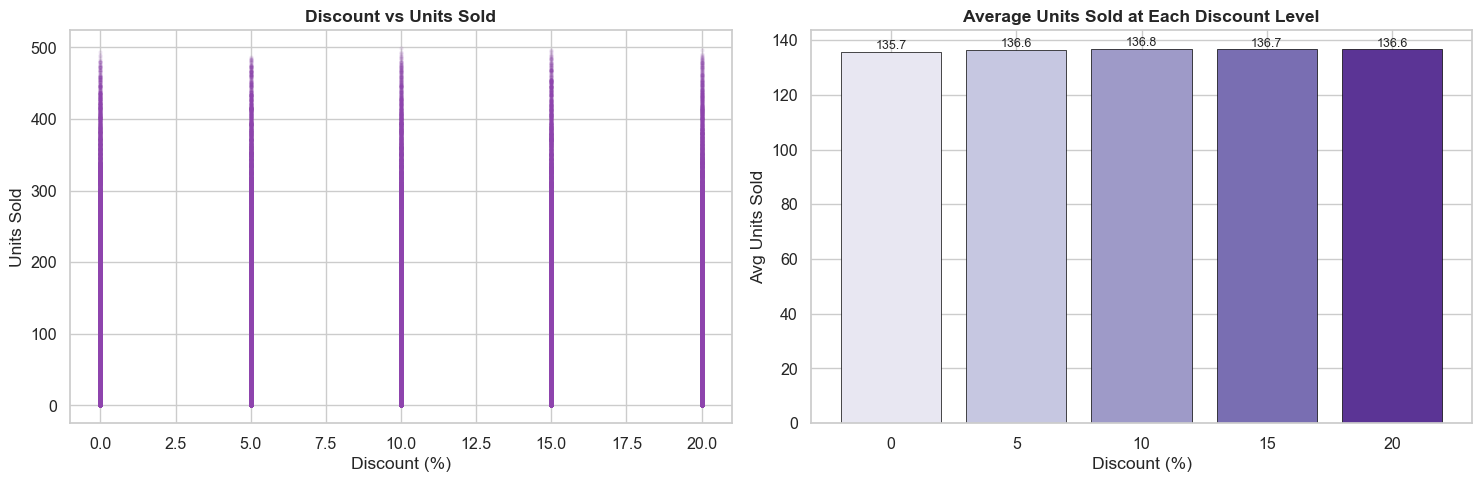

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Scatter: Discount vs Units Sold
axes[0].scatter(df['Discount'], df[TARGET], alpha=0.08, s=5, color='#8e44ad')
axes[0].set_xlabel('Discount (%)')
axes[0].set_ylabel(TARGET)
axes[0].set_title('Discount vs Units Sold', fontweight='bold')

# Avg Units Sold at each discount level
disc_avg = df.groupby('Discount')[TARGET].mean().sort_index()
axes[1].bar(disc_avg.index.astype(str), disc_avg.values,
            color=sns.color_palette('Purples', len(disc_avg)), edgecolor='black', linewidth=0.5)
axes[1].set_xlabel('Discount (%)')
axes[1].set_ylabel(f'Avg {TARGET}')
axes[1].set_title('Average Units Sold at Each Discount Level', fontweight='bold')

for bar in axes[1].patches:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{bar.get_height():.1f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

---
## 8. Price Analysis — How does pricing affect sales?

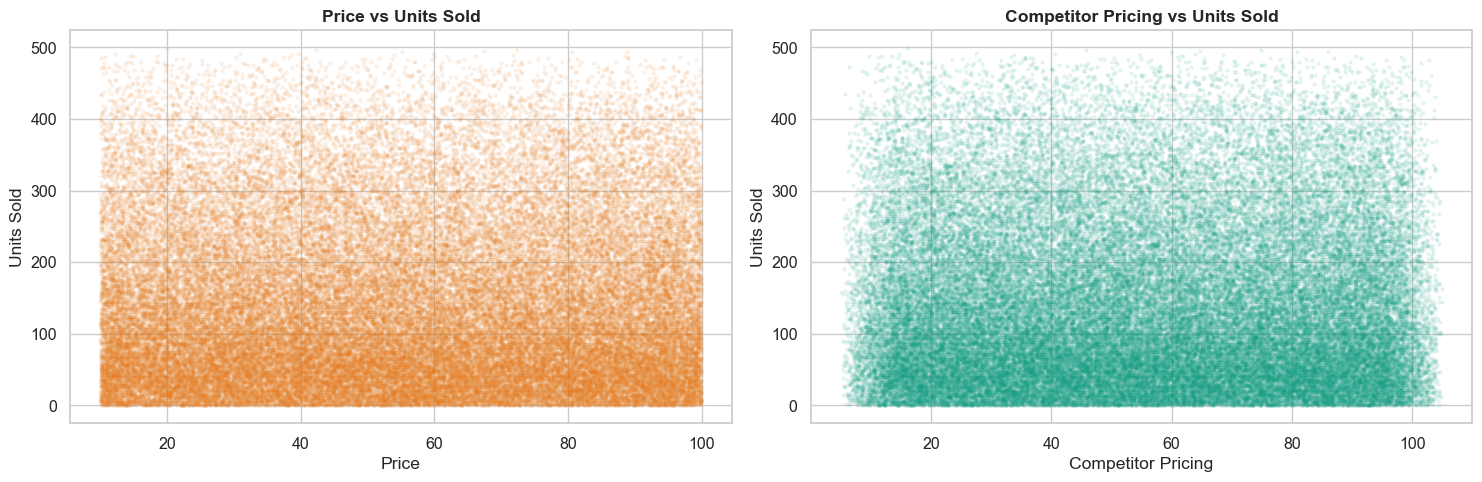

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Own Price vs Units Sold
axes[0].scatter(df['Price'], df[TARGET], alpha=0.08, s=5, color='#e67e22')
axes[0].set_xlabel('Price')
axes[0].set_ylabel(TARGET)
axes[0].set_title('Price vs Units Sold', fontweight='bold')

# Competitor Pricing vs Units Sold
axes[1].scatter(df['Competitor Pricing'], df[TARGET], alpha=0.08, s=5, color='#16a085')
axes[1].set_xlabel('Competitor Pricing')
axes[1].set_ylabel(TARGET)
axes[1].set_title('Competitor Pricing vs Units Sold', fontweight='bold')

plt.tight_layout()
plt.show()

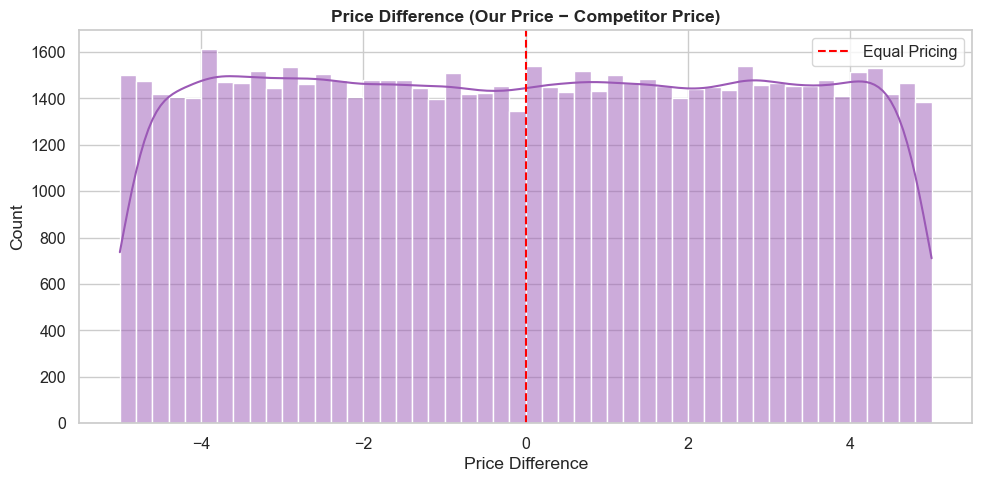

Average price difference: -0.01
We are cheaper than competitor in 50.0% of cases


In [14]:
# Is our price higher or lower than competitors on average?
df['Price_Diff'] = df['Price'] - df['Competitor Pricing']

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df['Price_Diff'], kde=True, bins=50, color='#9b59b6', ax=ax, edgecolor='white')
ax.axvline(0, color='red', linestyle='--', linewidth=1.5, label='Equal Pricing')
ax.set_title('Price Difference (Our Price − Competitor Price)', fontweight='bold')
ax.set_xlabel('Price Difference')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Average price difference: {df["Price_Diff"].mean():.2f}')
print(f'We are cheaper than competitor in {(df["Price_Diff"] < 0).mean()*100:.1f}% of cases')

# Clean up temp column
df.drop('Price_Diff', axis=1, inplace=True)

---
## 9. Time-Based Trends — Do sales change over time?

We look at monthly and day-of-week patterns.

In [15]:
# Create time features
df['Month'] = df['Date'].dt.month
df['DayOfWeek'] = df['Date'].dt.day_name()

print(f"Date range: {df['Date'].min().date()} to {df['Date'].max().date()}")

Date range: 2022-01-01 to 2024-01-01


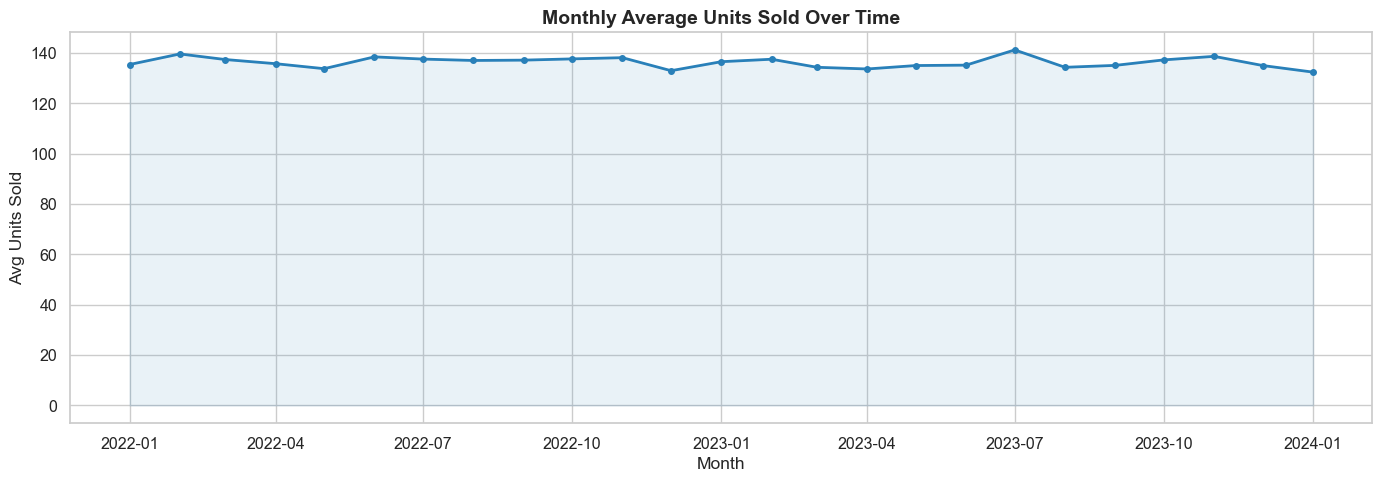

In [16]:
# Monthly trend
monthly = df.groupby(df['Date'].dt.to_period('M'))[TARGET].mean().reset_index()
monthly['Date'] = monthly['Date'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly['Date'], monthly[TARGET], color='#2980b9', linewidth=2, marker='o', markersize=4)
ax.fill_between(monthly['Date'], monthly[TARGET], alpha=0.1, color='#2980b9')
ax.set_title(f'Monthly Average {TARGET} Over Time', fontweight='bold', fontsize=14)
ax.set_xlabel('Month')
ax.set_ylabel(f'Avg {TARGET}')
plt.tight_layout()
plt.show()

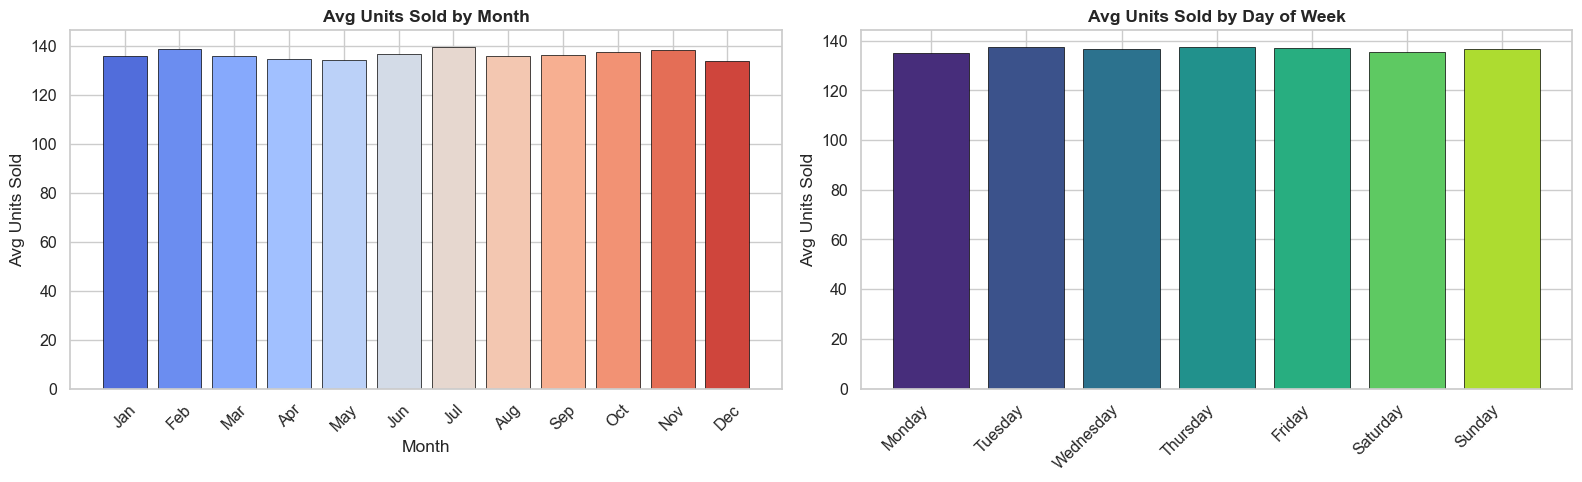

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Average Units Sold per Month (1-12)
month_avg = df.groupby('Month')[TARGET].mean()
axes[0].bar(month_avg.index, month_avg.values,
            color=sns.color_palette('coolwarm', 12), edgecolor='black', linewidth=0.5)
axes[0].set_title(f'Avg {TARGET} by Month', fontweight='bold')
axes[0].set_xlabel('Month')
axes[0].set_ylabel(f'Avg {TARGET}')
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                          'Jul','Aug','Sep','Oct','Nov','Dec'], rotation=45)

# Average Units Sold per Day of Week
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_avg = df.groupby('DayOfWeek')[TARGET].mean().reindex(day_order)
axes[1].bar(dow_avg.index, dow_avg.values,
            color=sns.color_palette('viridis', 7), edgecolor='black', linewidth=0.5)
axes[1].set_title(f'Avg {TARGET} by Day of Week', fontweight='bold')
axes[1].set_ylabel(f'Avg {TARGET}')
plt.setp(axes[1].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

---
## 10. Multi-Feature Analysis — Combining Insights

### 10.1 Category × Region — Where and what sells the most?

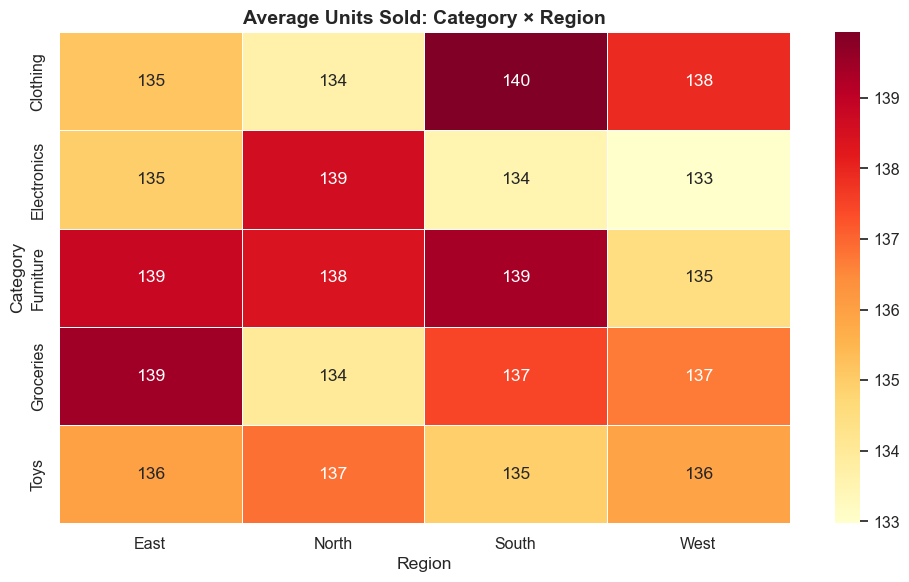

In [18]:
pivot = df.pivot_table(values=TARGET, index='Category', columns='Region', aggfunc='mean')

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.5, ax=ax)
ax.set_title(f'Average {TARGET}: Category × Region', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

### 10.2 Seasonality × Category — Which products sell in which season?

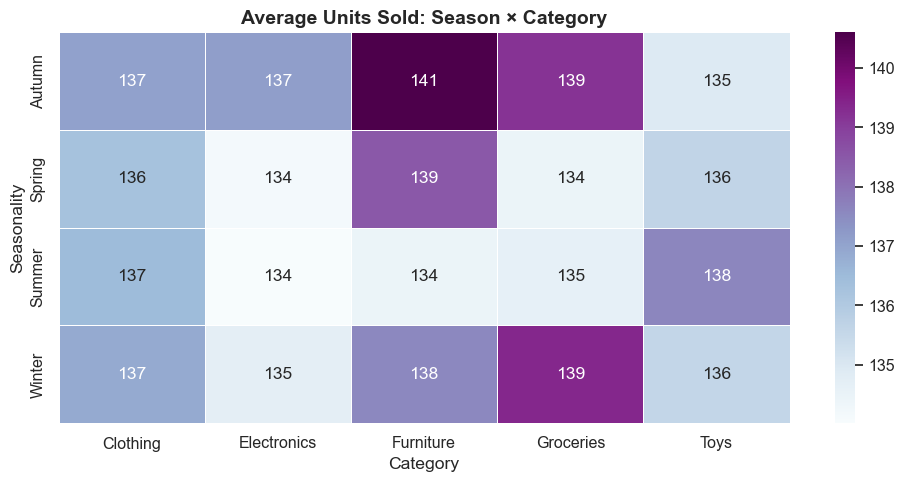

In [19]:
pivot2 = df.pivot_table(values=TARGET, index='Seasonality', columns='Category', aggfunc='mean')

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(pivot2, annot=True, fmt='.0f', cmap='BuPu', linewidths=0.5, ax=ax)
ax.set_title(f'Average {TARGET}: Season × Category', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

### 10.3 Weather × Category

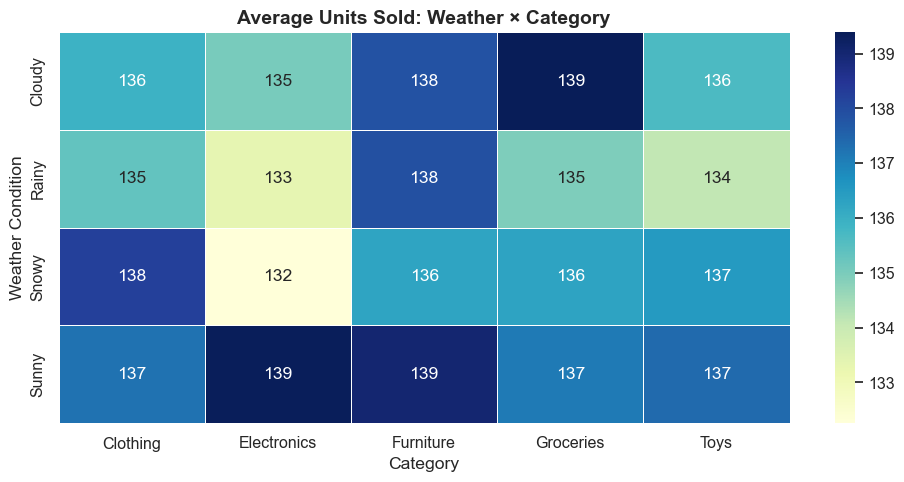

In [20]:
pivot3 = df.pivot_table(values=TARGET, index='Weather Condition', columns='Category', aggfunc='mean')

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(pivot3, annot=True, fmt='.0f', cmap='YlGnBu', linewidths=0.5, ax=ax)
ax.set_title(f'Average {TARGET}: Weather × Category', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

---
## 11. Inventory Level vs Units Sold — Supply & Demand Check

Does having more inventory lead to more sales, or is demand independent of stock?

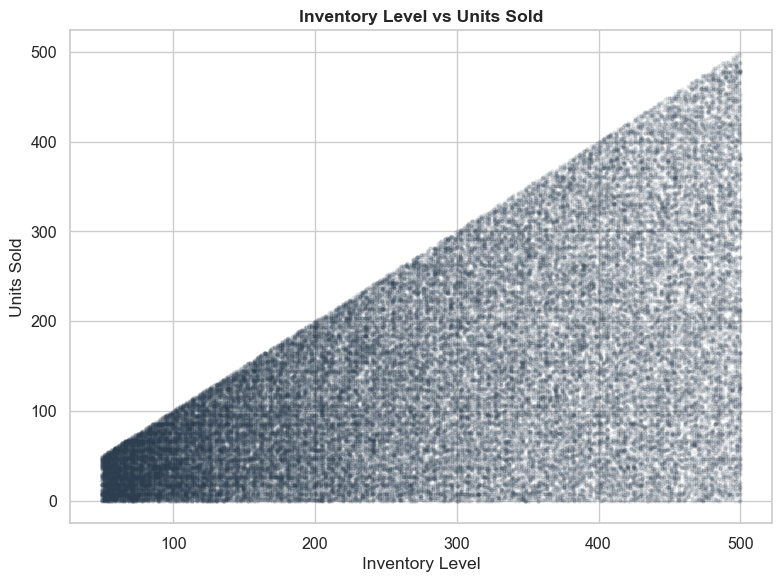

Correlation between Inventory Level and Units Sold: 0.590


In [21]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(df['Inventory Level'], df[TARGET], alpha=0.08, s=5, color='#2c3e50')
ax.set_xlabel('Inventory Level')
ax.set_ylabel(TARGET)
ax.set_title('Inventory Level vs Units Sold', fontweight='bold')
plt.tight_layout()
plt.show()

corr_val = df['Inventory Level'].corr(df[TARGET])
print(f'Correlation between Inventory Level and {TARGET}: {corr_val:.3f}')

---
## 12. Summary of Key Findings

In [22]:
# Final correlation ranking with target
print('='*55)
print(f'  FEATURE IMPORTANCE (Correlation with {TARGET})')
print('='*55)

final_corr = df[numerical_cols].corr()[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)

for feat, val in final_corr.items():
    bar = '█' * int(abs(val) * 30)
    sign = '+' if val >= 0 else '-'
    print(f'  {feat:25s} {sign}{abs(val):.3f}  {bar}')

  FEATURE IMPORTANCE (Correlation with Units Sold)
  Demand Forecast           +0.997  █████████████████████████████
  Inventory Level           +0.590  █████████████████
  Discount                  +0.003  
  Competitor Pricing        +0.001  
  Price                     +0.001  
  Units Ordered             -0.001  
  Holiday/Promotion         -0.000  


In [23]:
# Clean up helper columns before saving
df.drop(columns=['Month', 'DayOfWeek'], inplace=True, errors='ignore')
print('Temporary columns cleaned up.')

Temporary columns cleaned up.


---
## Key Takeaways

| # | Insight |
|---|--------|
| 1 | **Demand Forecast** is likely the strongest predictor of Units Sold |
| 2 | **Inventory Level** relates to sales — higher stock enables higher sales |
| 3 | **Category & Region** show different average sales — useful categorical features |
| 4 | **Seasonality & Weather** may influence sales patterns |
| 5 | **Discount & Holiday/Promotion** effects should be checked during modeling |
| 6 | **Price & Competitor Pricing** relationship with sales needs careful treatment |

### Next Steps
1. **Data Preprocessing** — Encode categoricals, scale numericals, handle outliers
2. **Feature Engineering** — Create new features (price ratio, lag features, rolling averages)
3. **Model Building** — Train regression models and evaluate with MAE, RMSE, R²